In [1]:
"""
Fragment 1 — Data Loading
==========================
VGG19 Binary Hybrid Pipeline — Feature Extraction + ML Classification

- Loads train, val and test data from disk
- Augmented folder already exists — no new augmentation
- Uses VGG19 preprocess_input to match training preprocessing
- All three sets loaded here since feature extraction
  requires passing images through VGG19 once
- shuffle=False on all sets — required for correct label
  alignment during feature extraction
- Binary classification — Mold vs No Mold
"""

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import preprocess_input

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# ── Safety Guards ─────────────────────────────────────────────────────────────

assert os.path.exists(AUG_DIR), \
    f"Augmented folder not found: {AUG_DIR}"
assert os.path.exists(VALID_DIR), \
    f"Validation folder not found: {VALID_DIR}"
assert os.path.exists(TEST_DIR), \
    f"Test folder not found: {TEST_DIR}"

# ── Step 1: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str, test_dir: str):
    """
    Builds generators for all three sets.
    All use VGG19 preprocess_input to match the preprocessing
    VGG19 expects — must be consistent across all sets.
    shuffle=False on all sets — critical for correct label
    alignment when extracting features batch by batch.
    class_mode = 'binary' — Mold vs No Mold.
    """

    train_datagen   = ImageDataGenerator(
                          preprocessing_function=preprocess_input)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    valid_datagen   = ImageDataGenerator(
                          preprocessing_function=preprocess_input)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    test_datagen   = ImageDataGenerator(
                         preprocessing_function=preprocess_input)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "binary",
        shuffle     = False,
    )

    return train_generator, valid_generator, test_generator

# ── Step 2: Run and Summarise ─────────────────────────────────────────────────

train_generator, valid_generator, test_generator = build_generators(
    AUG_DIR, VALID_DIR, TEST_DIR
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Fragment 1 — Data Generators Ready")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Model         : VGG19 + SVM / KNN (Hybrid)")
print(f"  Train source  : augmented/   (shared, no new aug)")
print(f"  Valid source  : val/")
print(f"  Test source   : test/")
print(f"  Preprocessing : VGG19 preprocess_input")
print(f"  Shuffle       : False on all sets (required for")
print(f"                  correct label alignment)")
print(f"  Train samples : {train_generator.samples}")
print(f"  Valid samples : {valid_generator.samples}")
print(f"  Test samples  : {test_generator.samples}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Class indices : {train_generator.class_indices}")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Batch size    : {BATCH_SIZE}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     train_generator, valid_generator and test_generator are ready.")
print("     Proceed to Fragment 2 — VGG19 Feature Extraction.\n")


Found 58813 images belonging to 2 classes.
Found 648 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
  Fragment 1 — Data Generators Ready
  Pipeline      : Binary — Mold vs No Mold
  Model         : VGG19 + SVM / KNN (Hybrid)
  Train source  : augmented/   (shared, no new aug)
  Valid source  : val/
  Test source   : test/
  Preprocessing : VGG19 preprocess_input
  Shuffle       : False on all sets (required for
                  correct label alignment)
  Train samples : 58813
  Valid samples : 648
  Test samples  : 649
  Classes       : ['Mold', 'No mold']
  Class indices : {'Mold': 0, 'No mold': 1}
  Image size    : (224, 224)
  Batch size    : 32

  ✓ Fragment 1 complete.
     train_generator, valid_generator and test_generator are ready.
     Proceed to Fragment 2 — VGG19 Feature Extraction.



In [2]:
"""
Fragment 2 — VGG19 Binary Feature Extraction
=============================================
VGG19 Binary Hybrid Pipeline — Feature Extraction + ML Classification

- Loads VGG19 with ImageNet weights
- Removes classification head — keeps convolutional base only
- Uses GlobalAveragePooling2D to produce 512 features per image
- Passes all three sets through VGG19 to extract features
- Features saved to disk as .npy files for reuse by
  Fragment 3 (SVM) and Fragment 4 (KNN)
- Extracted features reused without rerunning VGG19
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

SAVE_DIR    = r"D:\Mold Studies Binary\Models"
FEATURE_DIR = os.path.join(SAVE_DIR, "features", "vgg19_binary")

os.makedirs(FEATURE_DIR, exist_ok=True)

# ── Step 1: Build VGG19 Feature Extractor ────────────────────────────────────

def build_feature_extractor():
    """
    Loads VGG19 with ImageNet weights and removes the
    classification head entirely.

    VGG19 base output shape  : (7, 7, 512)
    After GlobalAveragePooling2D : (512,) features per image

    VGG19 produces 512 features after GAP — the most compact
    feature vector of all pretrained extractors in this project.
    Its depth comes from 16 convolutional layers organised into
    5 blocks with increasing filter counts up to 512.
    All layers are frozen — VGG19 is used purely as a
    fixed feature extractor, not trained further.
    """

    base_model = VGG19(
        input_shape = IMG_SHAPE,
        include_top = False,
        weights     = "imagenet"
    )

    base_model.trainable = False

    x      = base_model.output
    output = GlobalAveragePooling2D(name="gap")(x)

    feature_extractor = Model(
        inputs  = base_model.input,
        outputs = output,
        name    = "vgg19_binary_feature_extractor"
    )

    return feature_extractor, base_model

feature_extractor, base_model = build_feature_extractor()

total_params     = feature_extractor.count_params()
trainable_params = sum(tf.size(w).numpy()
                       for w in feature_extractor.trainable_weights)
frozen_params    = sum(tf.size(w).numpy()
                       for w in feature_extractor.non_trainable_weights)

print("=" * 60)
print("  Fragment 2 — VGG19 Binary Feature Extractor")
print("=" * 60)
print(f"  Pipeline         : Binary — Mold vs No Mold")
print(f"  Architecture     : VGG19")
print(f"  Weights          : ImageNet ✓")
print(f"  Input shape      : {IMG_SHAPE}")
print(f"  Base output      : (7, 7, 512)")
print(f"  After GAP        : 512 features per image")
print(f"  Total base layers: {len(base_model.layers)}")
print(f"  All layers frozen: ✓")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable        : {trainable_params:,}")
print(f"  Frozen           : {frozen_params:,}")
print("=" * 60)

# ── Step 2: Feature Extraction Function ──────────────────────────────────────

def extract_features(generator, extractor, set_name):
    """
    Passes all images through the VGG19 feature extractor.
    Returns feature matrix X and label array y.
    Generator must have shuffle=False for correct alignment.
    Features saved to disk as .npy files.
    If features already exist on disk they are loaded
    instead of recomputed — safe to rerun.
    """

    feat_path  = os.path.join(FEATURE_DIR, f"X_{set_name}.npy")
    label_path = os.path.join(FEATURE_DIR, f"y_{set_name}.npy")

    if os.path.exists(feat_path) and os.path.exists(label_path):
        print(f"  ✓ {set_name:<8} — loading from disk")
        X = np.load(feat_path)
        y = np.load(label_path)
        return X, y

    print(f"  Extracting {set_name} features...")
    generator.reset()

    X = extractor.predict(
        generator,
        steps   = np.ceil(generator.samples / generator.batch_size),
        verbose = 1,
    )
    y = generator.classes

    np.save(feat_path,  X)
    np.save(label_path, y)
    print(f"  ✓ {set_name:<8} — saved to disk  shape: {X.shape}")

    return X, y

# ── Step 3: Extract All Three Sets ───────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Extracting Features")
print("=" * 60)
print(f"  Feature dir : {FEATURE_DIR}")
print(f"  Note        : if features already exist on disk")
print(f"                they will be loaded instead of")
print(f"                recomputed — safe to rerun\n")

X_train, y_train = extract_features(train_generator,
                                     feature_extractor, "train")
X_val,   y_val   = extract_features(valid_generator,
                                     feature_extractor, "val")
X_test,  y_test  = extract_features(test_generator,
                                     feature_extractor, "test")

# ── Step 4: Summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Step 3 — Feature Extraction Complete")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Architecture  : VGG19 (frozen, no head)")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_val shape   : {X_val.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  Features      : {X_train.shape[1]:,} per image")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Saved to      : {FEATURE_DIR}")
print("=" * 60)

print("\n  ✓ Fragment 2 complete.")
print("     X_train, X_val, X_test, y_train, y_val, y_test are ready.")
print("     Proceed to Fragment 3 — SVM Classification.\n")
print("     Fragment 4 — KNN Classification will reuse")
print("     the same features without rerunning VGG19.\n")



  Fragment 2 — VGG19 Binary Feature Extractor
  Pipeline         : Binary — Mold vs No Mold
  Architecture     : VGG19
  Weights          : ImageNet ✓
  Input shape      : (224, 224, 3)
  Base output      : (7, 7, 512)
  After GAP        : 512 features per image
  Total base layers: 22
  All layers frozen: ✓
  Total params     : 20,024,384
  Trainable        : 0
  Frozen           : 20,024,384

  Step 2 — Extracting Features
  Feature dir : D:\Mold Studies Binary\Models\features\vgg19_binary
  Note        : if features already exist on disk
                they will be loaded instead of
                recomputed — safe to rerun

  Extracting train features...
1838/1838 [==============================] - 2504s 1s/step
  ✓ train    — saved to disk  shape: (58813, 512)
  Extracting val features...
21/21 [==============================] - 27s 1s/step
  ✓ val      — saved to disk  shape: (648, 512)
  Extracting test features...
21/21 [==============================] - 27s 1s/step
  ✓ tes

  Fragment 3 — VGG19 Binary + SVM  (5 Runs)
  Pipeline       : Binary — Mold vs No Mold
  Feature source : VGG19 extracted (512 features)
  Kernel         : linear
  C              : 1.0
  Threshold      : 0.5
  Max train      : 3000 samples (capped for speed)
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  VGG19 Binary + SVM
  Seed : 27

  Training SVM on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete

  Run 1 Results
    Accuracy     : 0.8675
    Precision    : 0.8667
    Sensitivity  : 0.9086
    Specificity  : 0.8123
    F1 Score     : 0.8871
    AUC          : 0.9293
    TP=338  TN=225  FP=52  FN=34


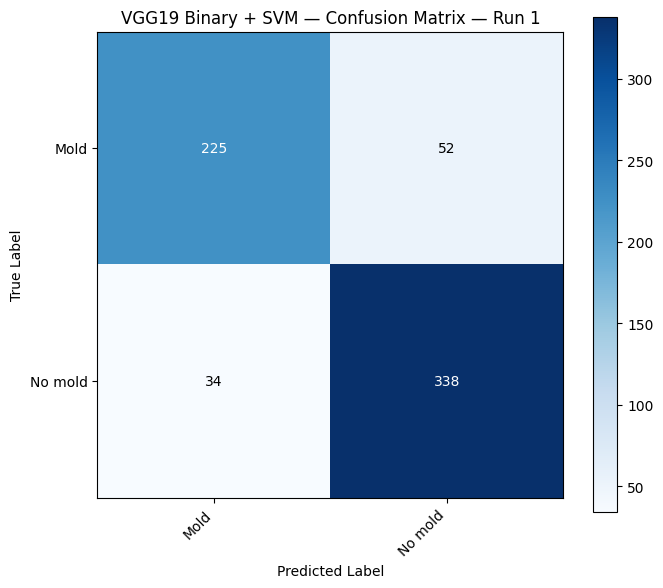

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_confusion_matrix_run1.png


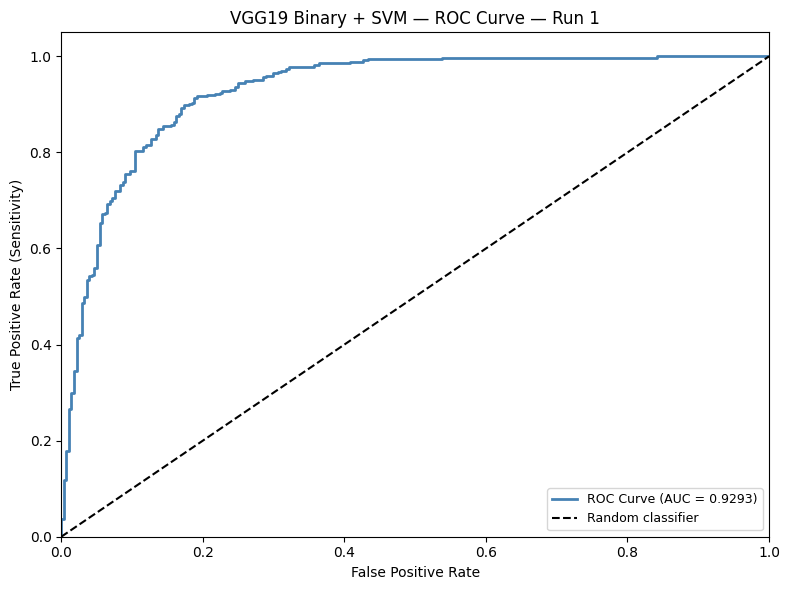

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_roc_curve_run1.png


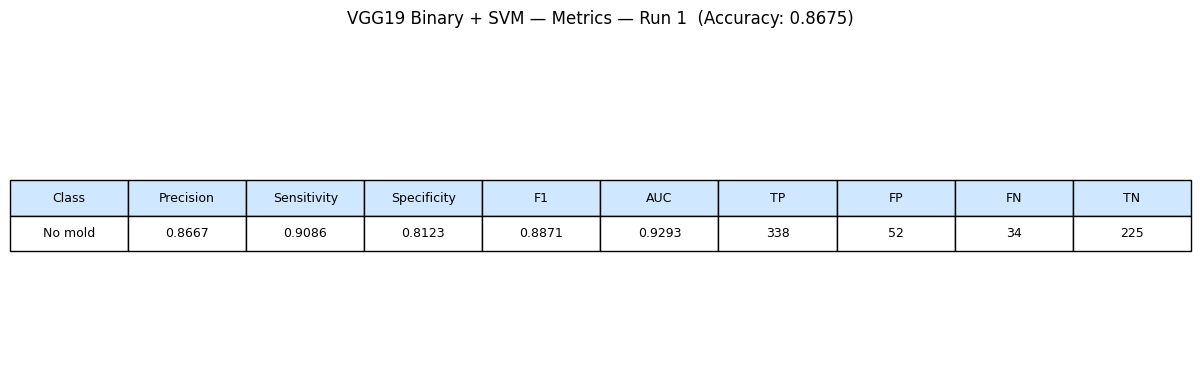

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_metrics_table_run1.png

  RUN 2 / 5  —  VGG19 Binary + SVM
  Seed : 42

  Training SVM on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete

  Run 2 Results
    Accuracy     : 0.8767
    Precision    : 0.8946
    Sensitivity  : 0.8898
    Specificity  : 0.8592
    F1 Score     : 0.8922
    AUC          : 0.9418
    TP=331  TN=238  FP=39  FN=41


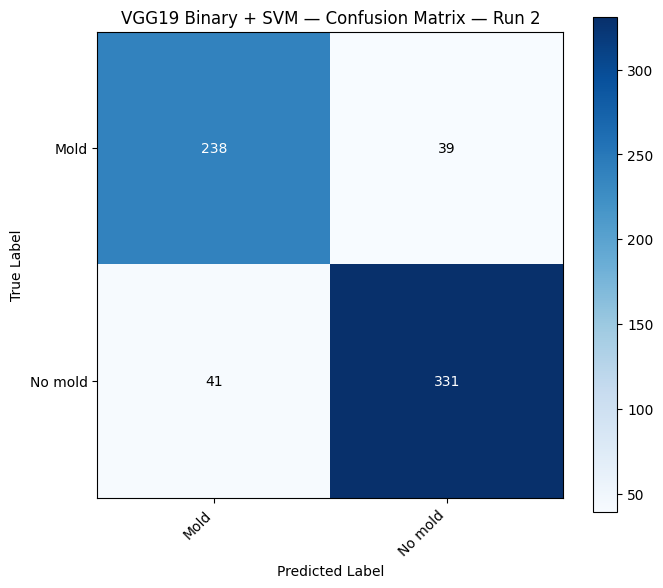

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_confusion_matrix_run2.png


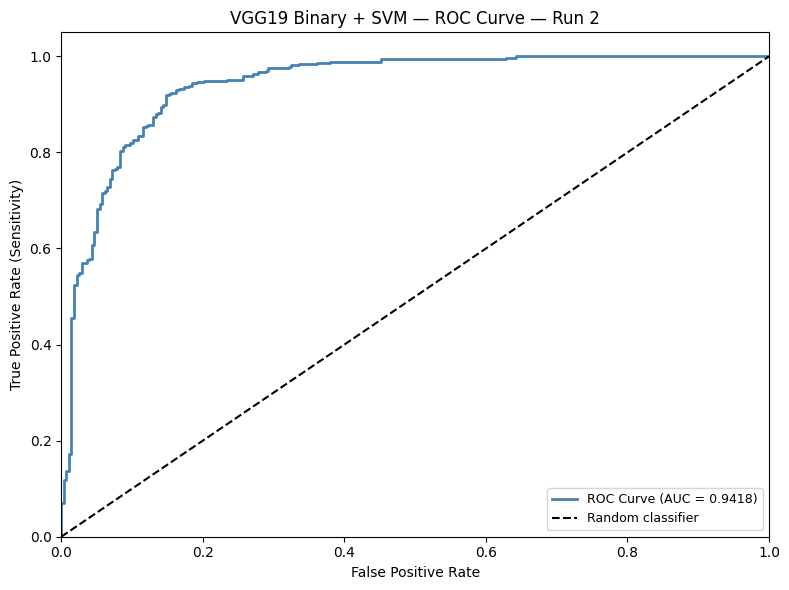

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_roc_curve_run2.png


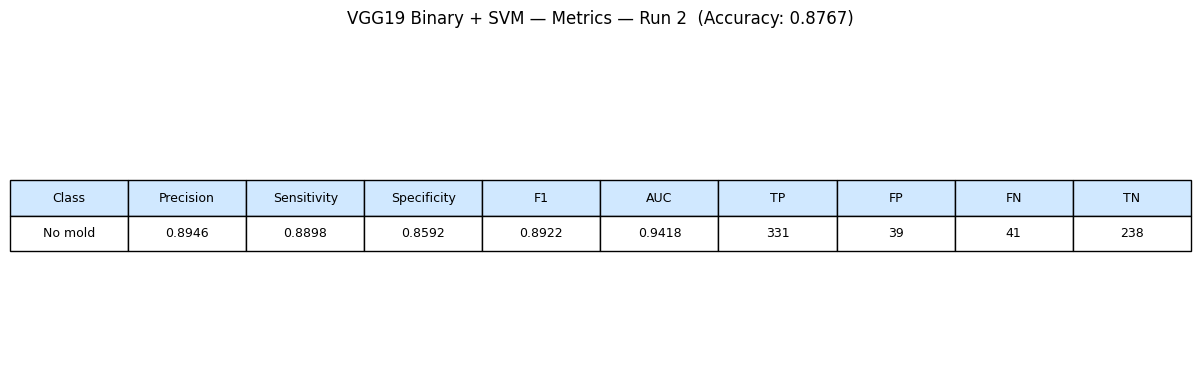

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_metrics_table_run2.png

  RUN 3 / 5  —  VGG19 Binary + SVM
  Seed : 99

  Training SVM on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete

  Run 3 Results
    Accuracy     : 0.8644
    Precision    : 0.8880
    Sensitivity  : 0.8737
    Specificity  : 0.8520
    F1 Score     : 0.8808
    AUC          : 0.9357
    TP=325  TN=236  FP=41  FN=47


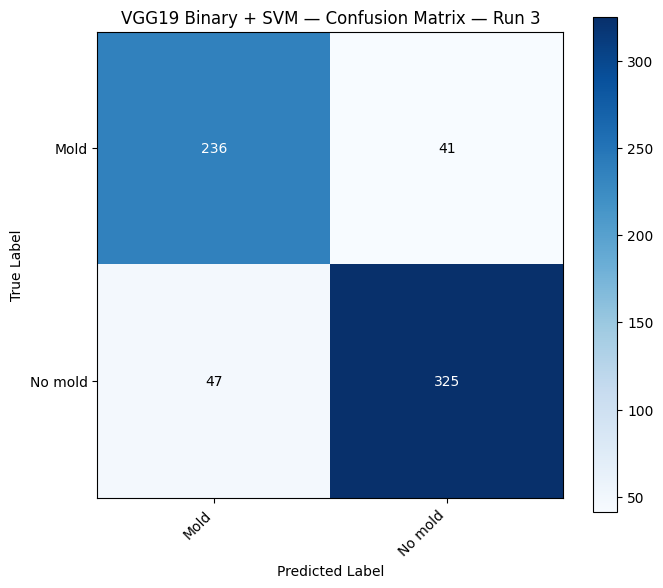

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_confusion_matrix_run3.png


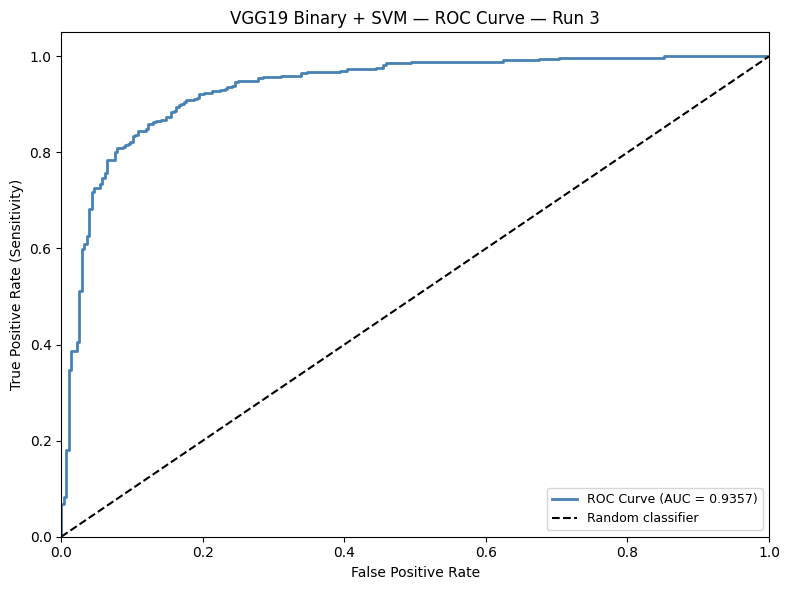

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_roc_curve_run3.png


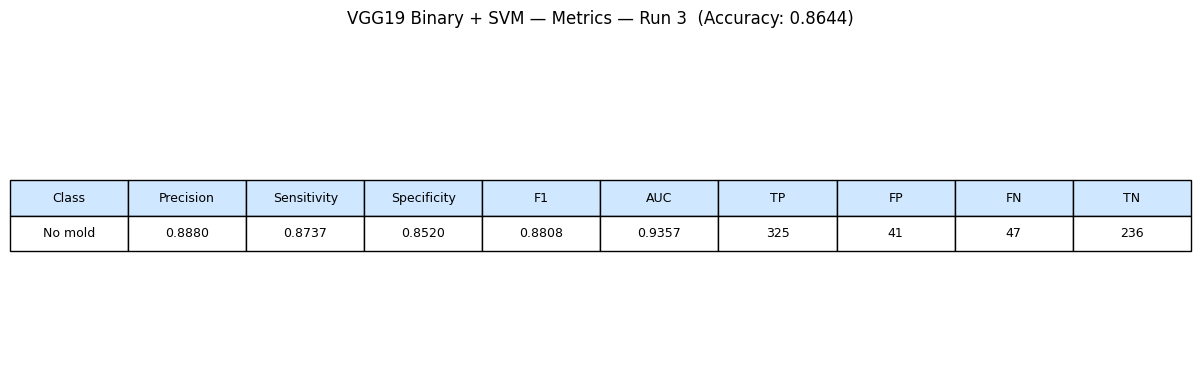

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_metrics_table_run3.png

  RUN 4 / 5  —  VGG19 Binary + SVM
  Seed : 123

  Training SVM on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete

  Run 4 Results
    Accuracy     : 0.8783
    Precision    : 0.8949
    Sensitivity  : 0.8925
    Specificity  : 0.8592
    F1 Score     : 0.8937
    AUC          : 0.9316
    TP=332  TN=238  FP=39  FN=40


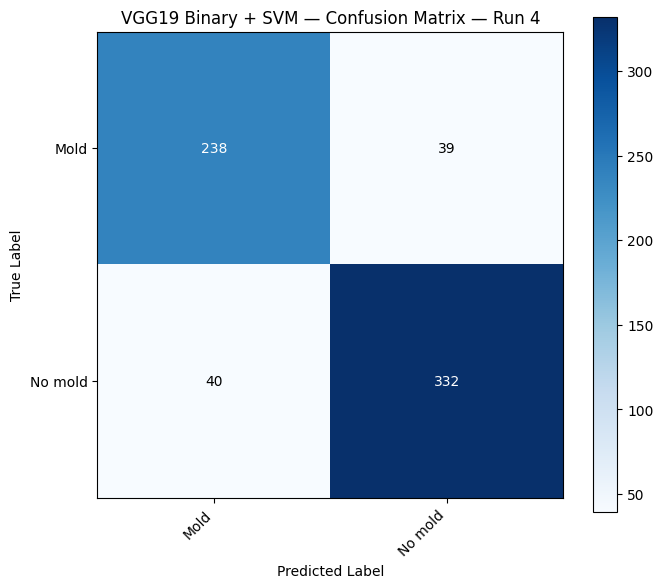

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_confusion_matrix_run4.png


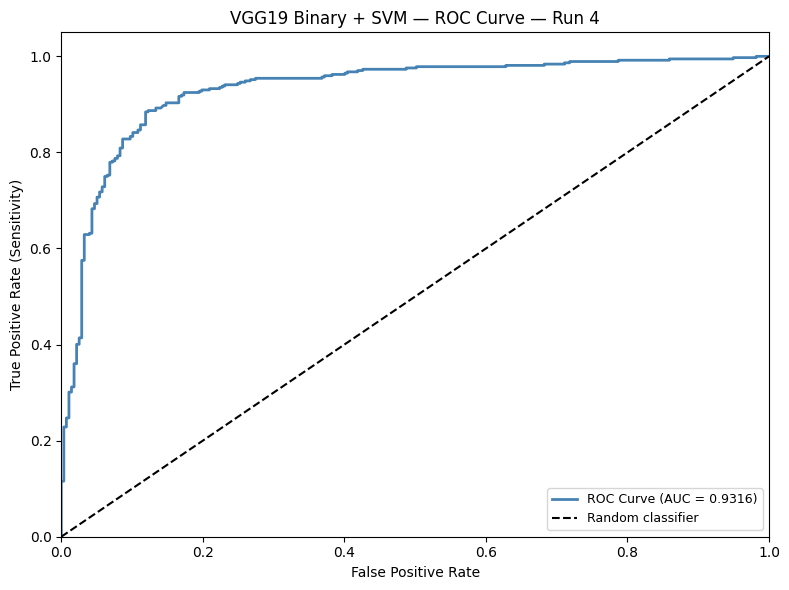

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_roc_curve_run4.png


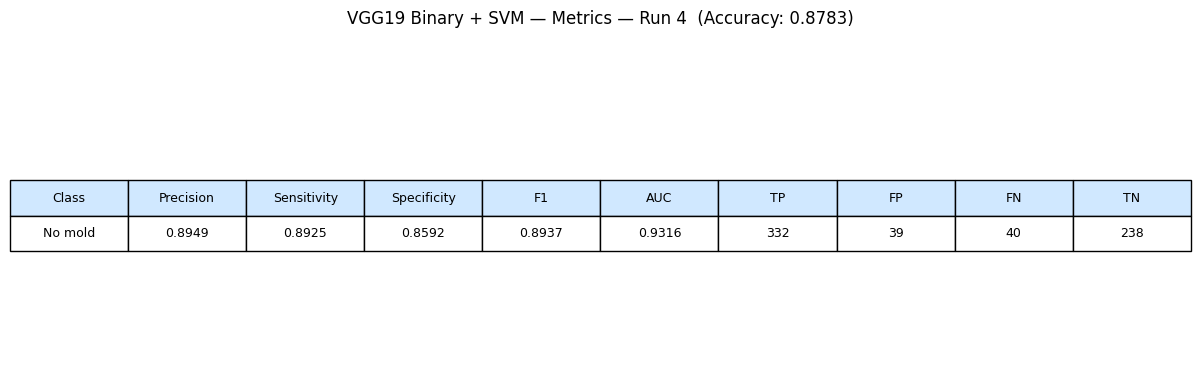

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_metrics_table_run4.png

  RUN 5 / 5  —  VGG19 Binary + SVM
  Seed : 256

  Training SVM on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete

  Run 5 Results
    Accuracy     : 0.8767
    Precision    : 0.9033
    Sensitivity  : 0.8790
    Specificity  : 0.8736
    F1 Score     : 0.8910
    AUC          : 0.9429
    TP=327  TN=242  FP=35  FN=45


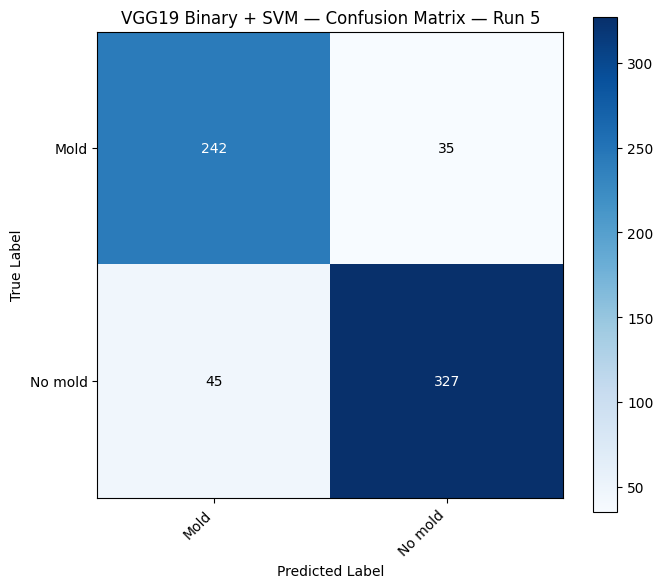

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_confusion_matrix_run5.png


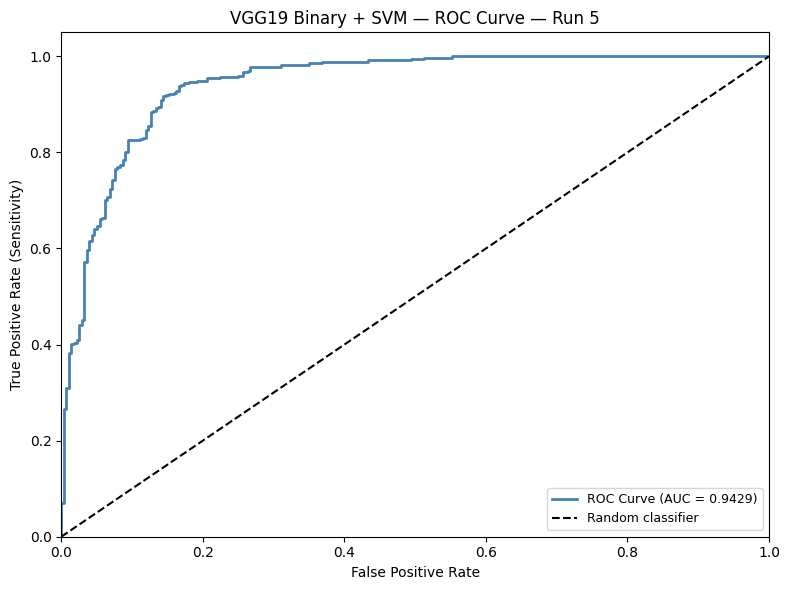

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_roc_curve_run5.png


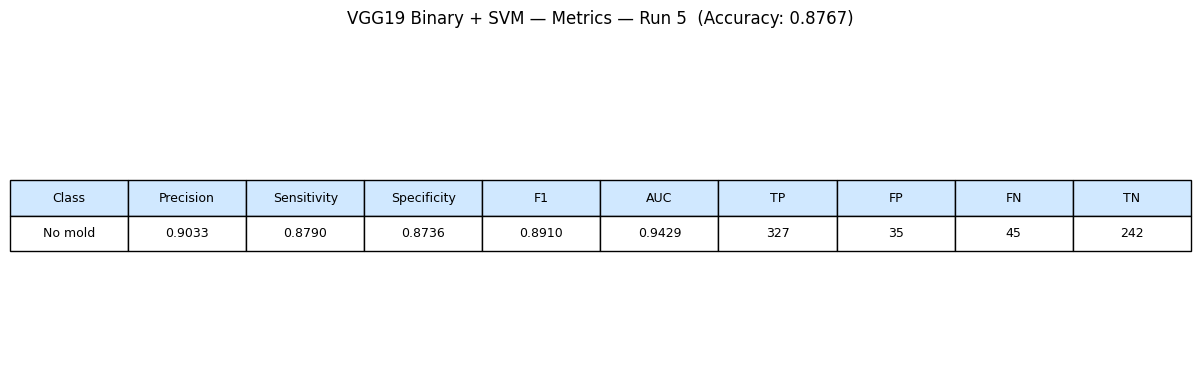

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_svm\vgg19_binary_svm_metrics_table_run5.png

  PER-RUN RESULTS — VGG19 Binary + SVM
  Run       Seed    Accuracy   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────────────
  1           27      0.8675      0.8667        0.9086        0.8123    0.8871    0.9293
  2           42      0.8767      0.8946        0.8898        0.8592    0.8922    0.9418
  3           99      0.8644      0.8880        0.8737        0.8520    0.8808    0.9357
  4          123      0.8783      0.8949        0.8925        0.8592    0.8937    0.9316
  5          256      0.8767      0.9033        0.8790        0.8736    0.8910    0.9429
──────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────  Statistical Summary  ────────────────────────────
  Metric              Mean       Std       Min       

In [3]:
"""
Fragment 3 — SVM Classification on VGG19 Binary Features (5 Runs)
===================================================================
VGG19 Binary Hybrid Pipeline — Feature Extraction + SVM

- Loads VGG19 binary extracted features from disk
- Trains SVM 5 times using different random seeds
- Each run shuffles and caps train features to MAX_TRAIN=3000
- Evaluates on test features — never seen during training
- Computes full binary metrics + 95% confidence intervals
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "vgg19_binary_svm")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]
MAX_TRAIN  = 3000    # cap training samples — large feature set needs this

os.makedirs(PLOT_DIR, exist_ok=True)

# ── SVM Parameters ────────────────────────────────────────────────────────────

SVM_KERNEL = "linear"
SVM_C      = 1.0
SVM_GAMMA  = "scale"
THRESHOLD  = 0.5

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    """
    Computes full binary evaluation metrics.
    y_prob is the probability for the positive class (column 1).
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"VGG19 Binary + SVM — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"vgg19_binary_svm_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"VGG19 Binary + SVM — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"vgg19_binary_svm_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [[
        CLASS_NAMES[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]
    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]
    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"VGG19 Binary + SVM — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"vgg19_binary_svm_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 3 — VGG19 Binary + SVM  (5 Runs)")
print("=" * 60)
print(f"  Pipeline       : Binary — Mold vs No Mold")
print(f"  Feature source : VGG19 extracted (512 features)")
print(f"  Kernel         : {SVM_KERNEL}")
print(f"  C              : {SVM_C}")
print(f"  Threshold      : {THRESHOLD}")
print(f"  Max train      : {MAX_TRAIN} samples (capped for speed)")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  VGG19 Binary + SVM")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train))[:MAX_TRAIN]
    X_tr    = X_train[indices]
    y_tr    = y_train[indices]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test)

    print(f"  Training SVM on VGG19 binary features...")
    print(f"  Training samples : {len(X_tr)} / {len(X_train)} (capped)")
    svm = SVC(
        kernel       = SVM_KERNEL,
        C            = SVM_C,
        gamma        = SVM_GAMMA,
        probability  = True,
        random_state = seed,
    )
    svm.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)[:, 1]

    metrics         = compute_metrics_binary(y_test, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "auc"        : metrics["auc"],
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_seed = 8
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — VGG19 Binary + SVM")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Accuracy':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_acc}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['specificity']:>{col_spec}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*28}  Statistical Summary  {'─'*28}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["auc"]         for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: Best Run ──────────────────────────────────────────────────────────

best_run = max(all_run_results, key=lambda x: x["auc"])

print(f"\n  Best run     : Run {best_run['run']} (by AUC)  "
      f"seed={best_run['seed']}")
print(f"  Accuracy     : {best_run['accuracy']:.4f}")
print(f"  Sensitivity  : {best_run['recall']:.4f}")
print(f"  Specificity  : {best_run['specificity']:.4f}")
print(f"  F1 Score     : {best_run['f1']:.4f}")
print(f"  AUC          : {best_run['auc']:.4f}")

# ── Step 6: Expose for comparison ─────────────────────────────────────────────

vgg19_binary_svm_all_metrics     = all_metrics
vgg19_binary_svm_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 3 complete.")
print(f"     vgg19_binary_svm_all_metrics and")
print(f"     vgg19_binary_svm_all_run_results ready.")
print(f"     Proceed to Fragment 4 — KNN on VGG19 binary features.\n")

  Fragment 4 — VGG19 Binary + KNN  (5 Runs)
  Pipeline       : Binary — Mold vs No Mold
  Feature source : VGG19 extracted (512 features)
  N Neighbours   : 5
  Metric         : euclidean
  Weights        : distance
  Max train      : 3000 samples (capped for speed)
  Seeds          : [27, 42, 99, 123, 256]

  RUN 1 / 5  —  VGG19 Binary + KNN
  Seed : 27

  Training KNN on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete
  Predicting...

  Run 1 Results
    Accuracy     : 0.8783
    Precision    : 0.8886
    Sensitivity  : 0.9005
    Specificity  : 0.8484
    F1 Score     : 0.8945
    AUC          : 0.9505
    TP=335  TN=235  FP=42  FN=37


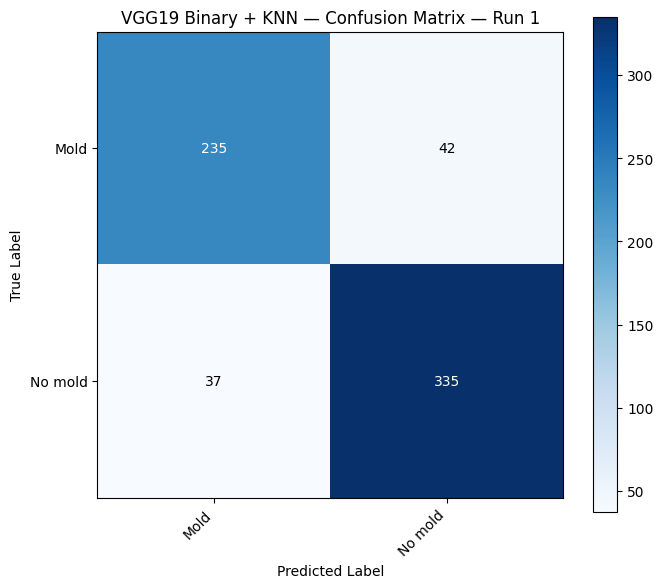

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_confusion_matrix_run1.png


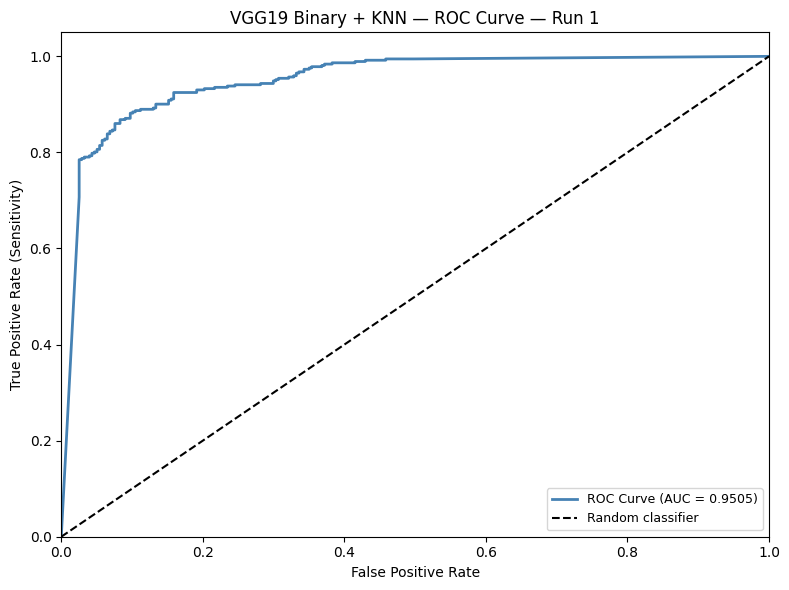

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_roc_curve_run1.png


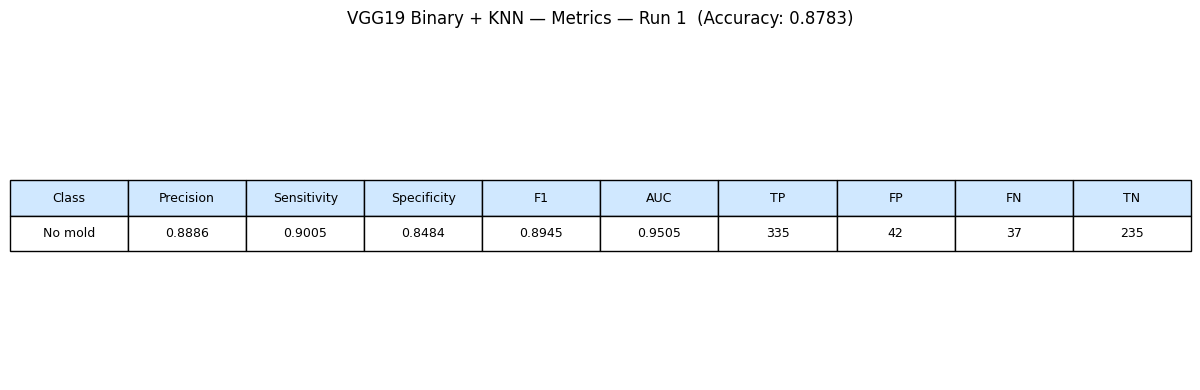

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_metrics_table_run1.png

  RUN 2 / 5  —  VGG19 Binary + KNN
  Seed : 42

  Training KNN on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete
  Predicting...

  Run 2 Results
    Accuracy     : 0.9060
    Precision    : 0.9331
    Sensitivity  : 0.9005
    Specificity  : 0.9134
    F1 Score     : 0.9166
    AUC          : 0.9650
    TP=335  TN=253  FP=24  FN=37


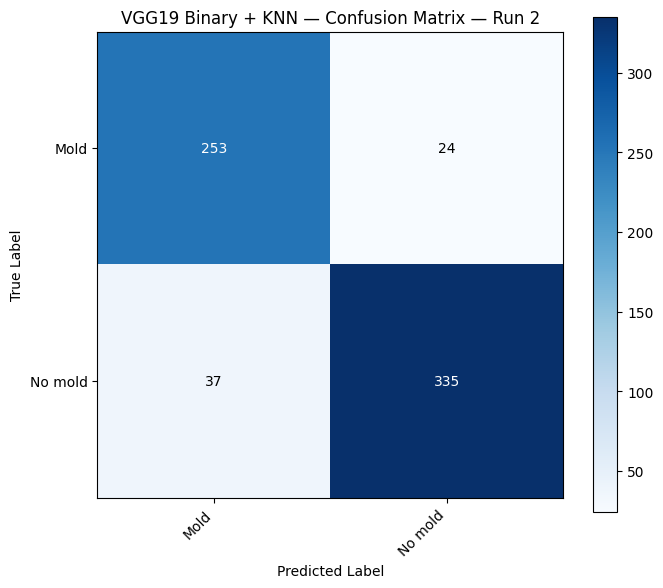

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_confusion_matrix_run2.png


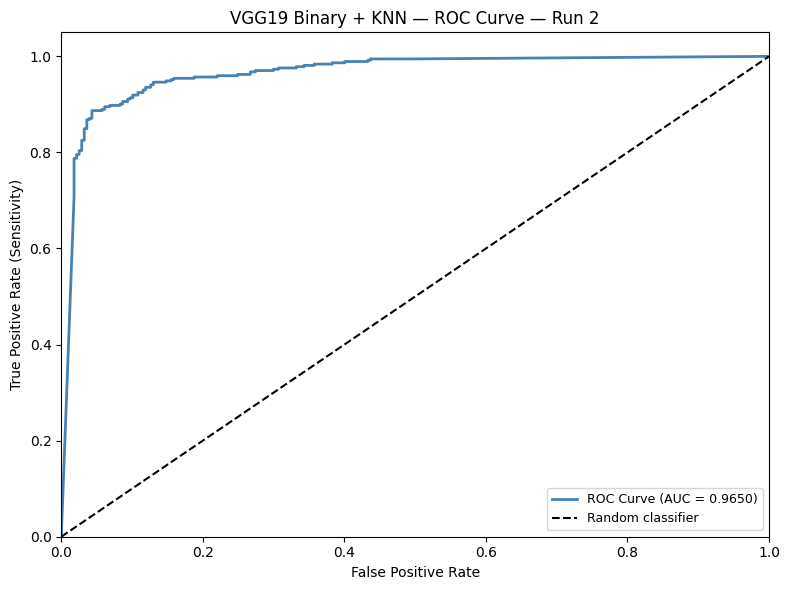

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_roc_curve_run2.png


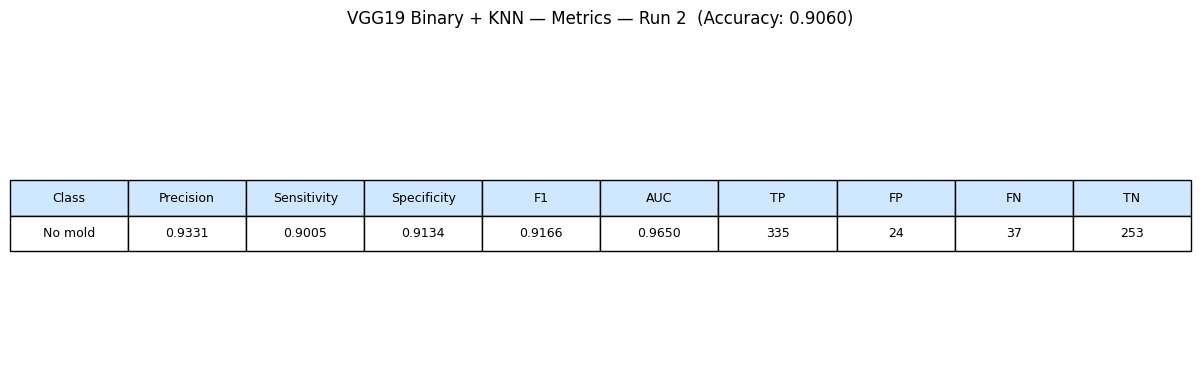

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_metrics_table_run2.png

  RUN 3 / 5  —  VGG19 Binary + KNN
  Seed : 99

  Training KNN on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete
  Predicting...

  Run 3 Results
    Accuracy     : 0.8706
    Precision    : 0.8850
    Sensitivity  : 0.8898
    Specificity  : 0.8448
    F1 Score     : 0.8874
    AUC          : 0.9488
    TP=331  TN=234  FP=43  FN=41


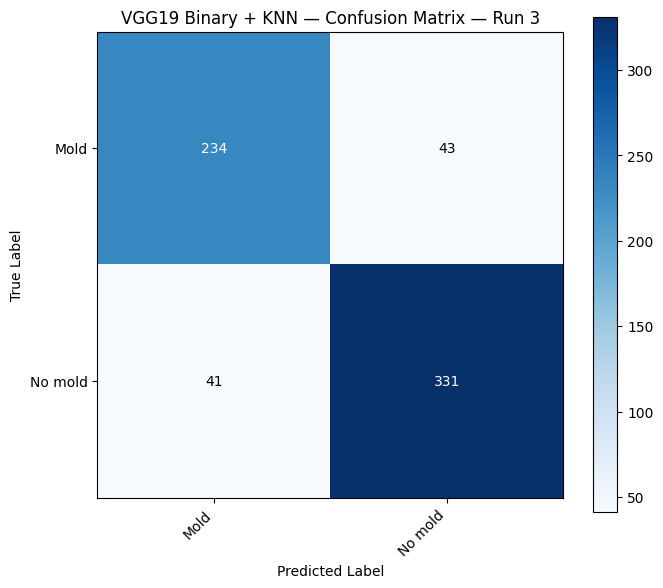

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_confusion_matrix_run3.png


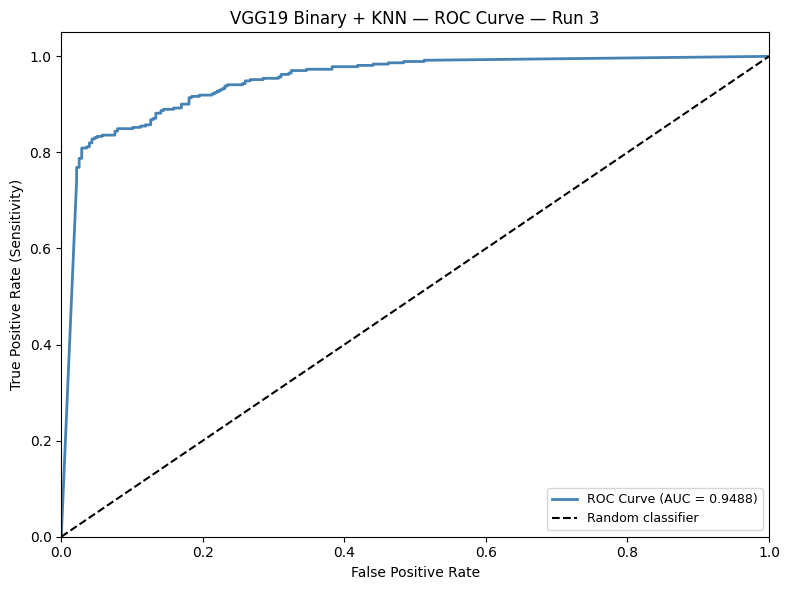

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_roc_curve_run3.png


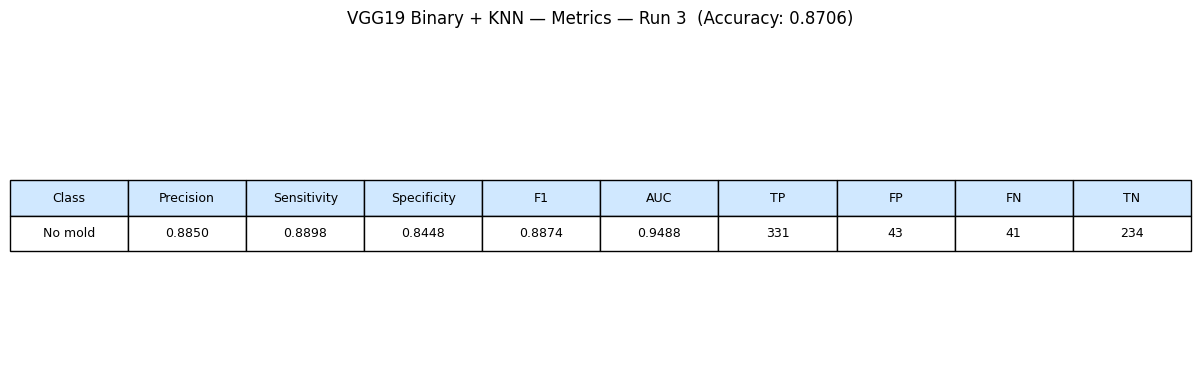

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_metrics_table_run3.png

  RUN 4 / 5  —  VGG19 Binary + KNN
  Seed : 123

  Training KNN on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete
  Predicting...

  Run 4 Results
    Accuracy     : 0.8875
    Precision    : 0.8824
    Sensitivity  : 0.9274
    Specificity  : 0.8339
    F1 Score     : 0.9043
    AUC          : 0.9554
    TP=345  TN=231  FP=46  FN=27


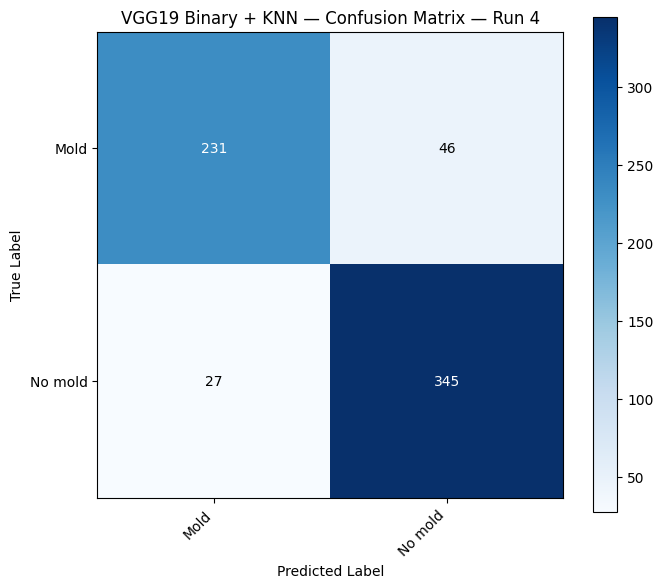

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_confusion_matrix_run4.png


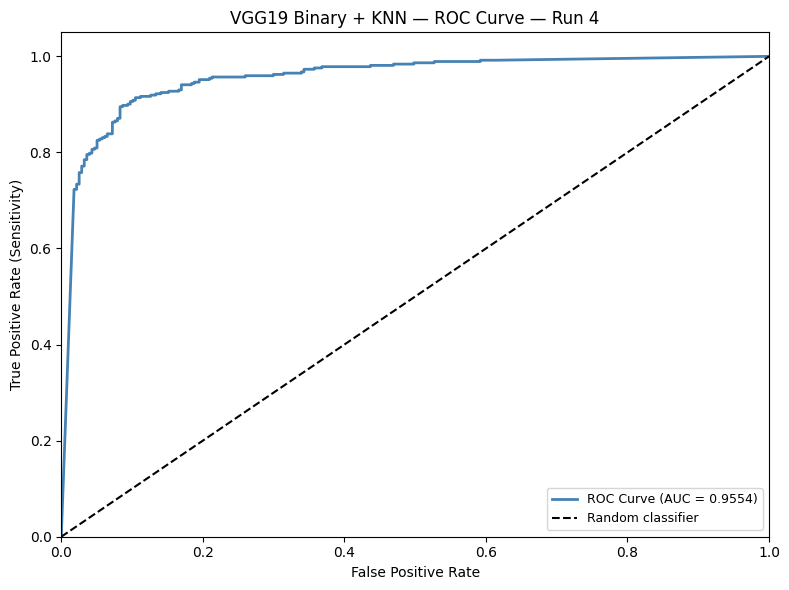

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_roc_curve_run4.png


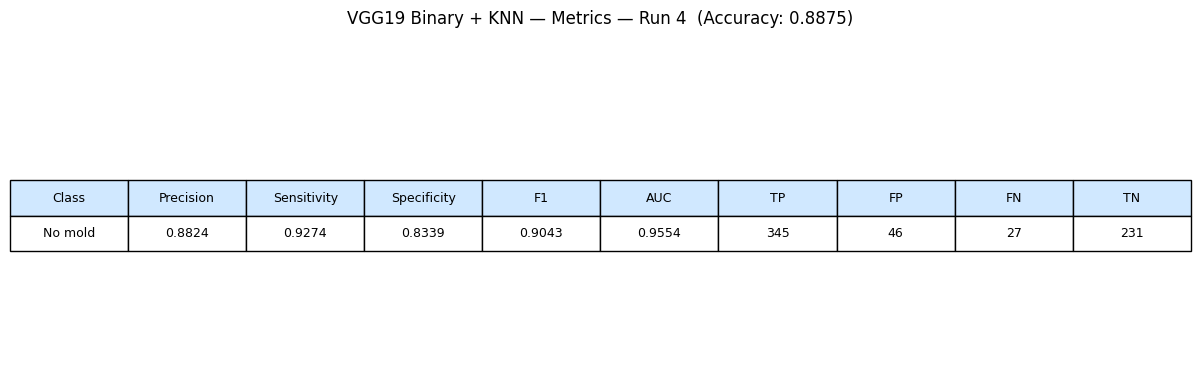

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_metrics_table_run4.png

  RUN 5 / 5  —  VGG19 Binary + KNN
  Seed : 256

  Training KNN on VGG19 binary features...
  Training samples : 3000 / 58813 (capped)
  ✓ Training complete
  Predicting...

  Run 5 Results
    Accuracy     : 0.9029
    Precision    : 0.9187
    Sensitivity  : 0.9113
    Specificity  : 0.8917
    F1 Score     : 0.9150
    AUC          : 0.9687
    TP=339  TN=247  FP=30  FN=33


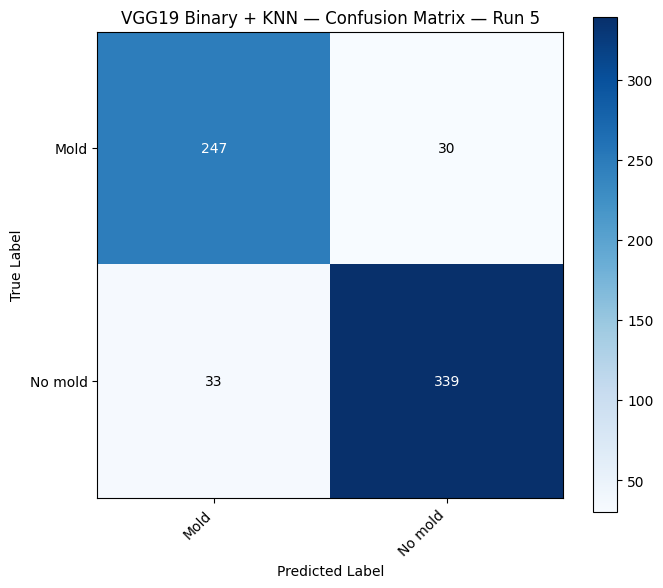

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_confusion_matrix_run5.png


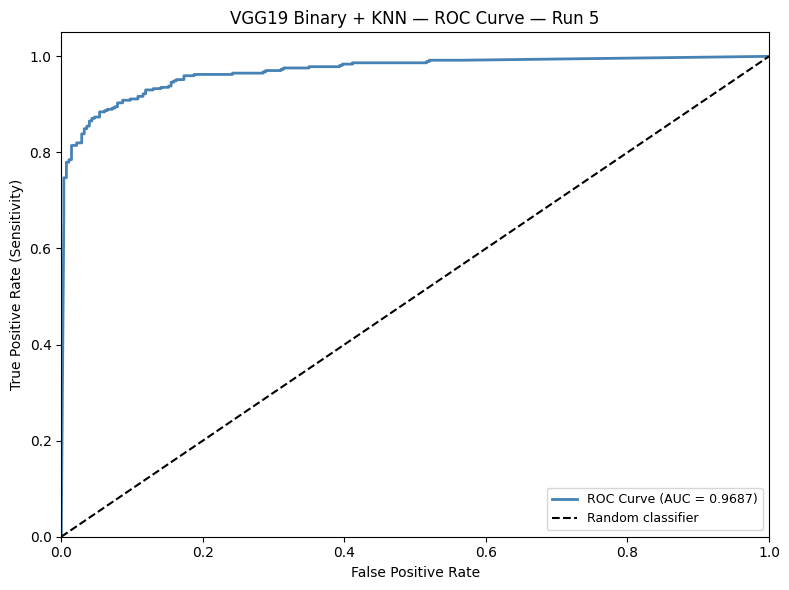

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_roc_curve_run5.png


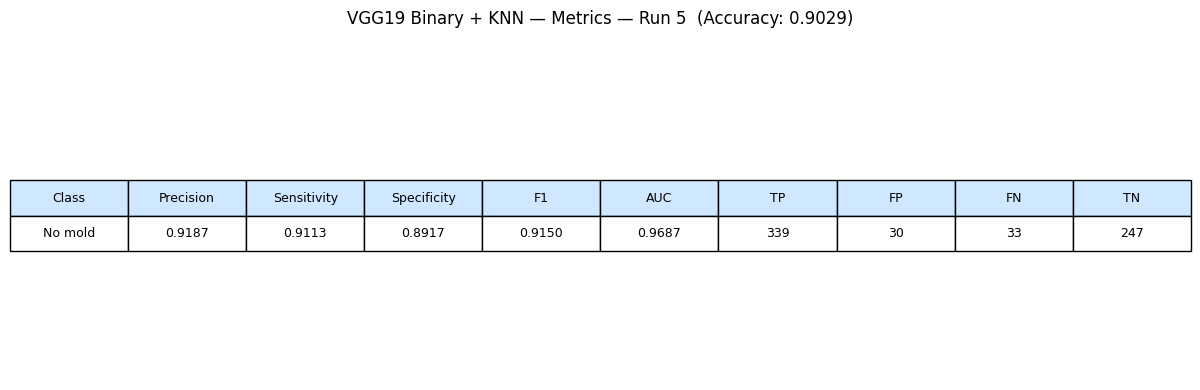

  Saved: D:\Mold Studies Binary\Models\plots\vgg19_binary_knn\vgg19_binary_knn_metrics_table_run5.png

  PER-RUN RESULTS — VGG19 Binary + KNN
  Run       Seed    Accuracy   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────────────
  1           27      0.8783      0.8886        0.9005        0.8484    0.8945    0.9505
  2           42      0.9060      0.9331        0.9005        0.9134    0.9166    0.9650
  3           99      0.8706      0.8850        0.8898        0.8448    0.8874    0.9488
  4          123      0.8875      0.8824        0.9274        0.8339    0.9043    0.9554
  5          256      0.9029      0.9187        0.9113        0.8917    0.9150    0.9687
──────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────  Statistical Summary  ────────────────────────────
  Metric              Mean       Std       Min       

In [4]:
"""
Fragment 4 — KNN Classification on VGG19 Binary Features (5 Runs)
===================================================================
VGG19 Binary Hybrid Pipeline — Feature Extraction + KNN

- Reuses VGG19 binary extracted features already on disk
- Trains KNN 5 times using different random seeds
- Each run shuffles and caps train features to MAX_TRAIN=3000
- Evaluates on test features — never seen during training
- Computes full binary metrics + 95% confidence intervals
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
)
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "vgg19_binary_knn")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]
MAX_TRAIN  = 3000    # cap training samples — large feature set needs this

os.makedirs(PLOT_DIR, exist_ok=True)

# ── KNN Parameters ────────────────────────────────────────────────────────────

KNN_N_NEIGHBORS = 5
KNN_METRIC      = "euclidean"
KNN_WEIGHTS     = "distance"
THRESHOLD       = 0.5

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    """
    Computes full binary evaluation metrics.
    y_prob is the probability for the positive class (column 1).
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"VGG19 Binary + KNN — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"vgg19_binary_knn_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"VGG19 Binary + KNN — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"vgg19_binary_knn_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [[
        CLASS_NAMES[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]
    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]
    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"VGG19 Binary + KNN — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"vgg19_binary_knn_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 4 — VGG19 Binary + KNN  (5 Runs)")
print("=" * 60)
print(f"  Pipeline       : Binary — Mold vs No Mold")
print(f"  Feature source : VGG19 extracted (512 features)")
print(f"  N Neighbours   : {KNN_N_NEIGHBORS}")
print(f"  Metric         : {KNN_METRIC}")
print(f"  Weights        : {KNN_WEIGHTS}")
print(f"  Max train      : {MAX_TRAIN} samples (capped for speed)")
print(f"  Seeds          : {SEEDS}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  VGG19 Binary + KNN")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train))[:MAX_TRAIN]
    X_tr    = X_train[indices]
    y_tr    = y_train[indices]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test)

    print(f"  Training KNN on VGG19 binary features...")
    print(f"  Training samples : {len(X_tr)} / {len(X_train)} (capped)")
    knn = KNeighborsClassifier(
        n_neighbors = KNN_N_NEIGHBORS,
        metric      = KNN_METRIC,
        weights     = KNN_WEIGHTS,
        n_jobs      = -1,
    )
    knn.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    print(f"  Predicting...")
    y_pred = knn.predict(X_te_sc)
    y_prob = knn.predict_proba(X_te_sc)[:, 1]

    metrics         = compute_metrics_binary(y_test, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "auc"        : metrics["auc"],
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_seed = 8
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — VGG19 Binary + KNN")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Accuracy':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_acc}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['specificity']:>{col_spec}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*28}  Statistical Summary  {'─'*28}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["auc"]         for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: SVM vs KNN Comparison ─────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  VGG19 Binary HYBRID — SVM vs KNN Comparison")
print(f"{'='*60}")
print(f"  {'Metric':<14} {'SVM Mean':>12} {'KNN Mean':>12} {'Winner':>10}")
print(f"  {'─'*50}")

comparison_metrics = {
    "Accuracy"   : "accuracy",
    "Precision"  : "precision",
    "Sensitivity": "recall",
    "Specificity": "specificity",
    "F1 Score"   : "f1",
    "AUC"        : "auc",
}

for label, key in comparison_metrics.items():
    svm_mean = np.mean([r[key] for r in vgg19_binary_svm_all_run_results])
    knn_mean = np.mean([r[key] for r in all_run_results])
    winner   = "SVM" if svm_mean >= knn_mean else "KNN"
    print(
        f"  {label:<14}"
        f"{svm_mean:>12.4f}"
        f"{knn_mean:>12.4f}"
        f"{winner:>10}"
    )

print(f"{'='*60}")

# ── Step 6: Expose for comparison ─────────────────────────────────────────────

vgg19_binary_knn_all_metrics     = all_metrics
vgg19_binary_knn_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     vgg19_binary_knn_all_metrics and")
print(f"     vgg19_binary_knn_all_run_results ready.")
print(f"     Proceed to Binary Fragment 5 — Cross-Model Comparison.\n")